In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01010
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1214.8607754997602
RUN  2 , total integrated cost =  220.65900370108346
RUN  3 , total integrated cost =  106.80313385038696
RUN  4 , total integrated cost =  19.83441935245901
RUN  5 , total integrated cost =  18.332585410438945
RUN  6 , total integrated cost =  16.746012942355296
RUN  7 , total integrated cost =  15.660390012055887
RUN  8 , total integrated cost =  14.544178897041077
RUN  9 , total integrated cost =  13.625583827784723
RUN  10 , total integrated cost =  12.857445515000377
RUN  11 , total integrated cost =  11.808698580804997
RUN  12 , total integrated cost =  10.986213006985341
RUN  13 , total integrated cost =  10.487797512020435
RUN  14 , total integrated cost =  10.159351916074579
RUN  15 , total integrated cost =  10.095753023597073

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  9.002214134086712
Control only changes marginally.
RUN  41 , total integrated cost =  9.002214134086712
Improved over  41  iterations in  12.317354273051023  seconds by  99.84748230800858  percent.
Problem in initial value trasfer:  Vmean_exc -56.627610777868966 -56.627611258587805
weight =  6556.616396058647
set cost params:  1.0 6556.616396058647 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5846.098500984984
Gradient descend method:  None
RUN  1 , total integrated cost =  4164.690876893683
RUN  2 , total integrated cost =  4163.519935527499
RUN  3 , total integrated cost =  4163.197533759545
RUN  4 , total integrated cost =  4162.373999273211
RUN  5 , total integrated cost =  4124.0493465800455
RUN  6 , total integrated cost =  4118.178201246843
RUN  7 , total integrated cost =  4118.114155762954
RUN  8 , total integrated cost =  4118.10865963353
RUN  9 , total integrated cost =  4118.107927189125
RUN  10 , total integ

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  28 , total integrated cost =  4118.107686638131
Improved over  28  iterations in  0.6550820358097553  seconds by  29.55801743771015  percent.
Problem in initial value trasfer:  Vmean_exc -56.62687215656052 -56.62684083003213
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  358.442399145548
RUN  2 , total integrated cost =  58.270154204703715
RUN  3 , total integrated cost =  54.101508961547125
RUN  4 , total integrated cost =  41.78139610676152
RUN  5 , total integrated cost =  18.809544470854824
RUN  6 , total integrated cost =  18.590878783214954
RUN  7 , total integrated cost =  18.510987916422362
RUN  8 , total integrated cost =  17.293387882786558
RUN  9 , total integrated cost =  16.773168868764472
RUN  10 , total integrated cost =  16.761895479846718
RUN  1

...

Control only changes marginally.
RUN  33 , total integrated cost =  28725.797716941994
Improved over  33  iterations in  0.7525225505232811  seconds by  12.03222202488358  percent.
Problem in initial value trasfer:  Vmean_exc -56.70334895098804 -56.703348708396156
-------  112 0.5500000000000003 0.8000000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28715.541829737766
Gradient descend method:  None
RUN  1 , total integrated cost =  28715.54164618205
RUN  2 , total integrated cost =  28715.541646182035
RUN  3 , total integrated cost =  28715.541646182035
Control only changes marginally.
RUN  3 , total integrated cost =  28715.541646182035
Improved over  3  iterations in  0.11755614541471004  seconds by  6.392208575789482e-07  percent.
Problem in initial value trasfer:  Vmean_exc -70.4973202476074 -70.4973264551731
weight =  10.000000063922085
set cost params:  1.0 10.000000063922085 0.0
interpolate adjoint :  True True T

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  28715.54164618203
RUN  3 , total integrated cost =  28715.54164618203
Control only changes marginally.
RUN  3 , total integrated cost =  28715.54164618203
Improved over  3  iterations in  0.12408680655062199  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -70.49732024764177 -70.49732645520733
-------  119 0.5250000000000001 0.8250000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.516518906425
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.516518603203
RUN  2 , total integrated cost =  23752.516518603185
RUN  3 , total integrated cost =  23752.51651860318
RUN  4 , total integrated cost =  23752.51651860318
Control only changes marginally.
RUN  4 , total integrated cost =  23752.51651860318
Improved over  4  iterations in  0.12235760316252708  seconds by  1.2766747659043176e-09  percent.
Problem in initial value trasfer

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23752.51651860318
Control only changes marginally.
RUN  1 , total integrated cost =  23752.51651860318
Improved over  1  iterations in  0.05837516859173775  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.24160276209989 -73.24160298580229
-------  126 0.5000000000000002 0.8500000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.9785373305
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.978537330313
RUN  2 , total integrated cost =  19001.978537330313
Control only changes marginally.
RUN  2 , total integrated cost =  19001.978537330313
Improved over  2  iterations in  0.07715764455497265  seconds by  9.805489753489383e-13  percent.
weight =  10.000000000000098
set cost params:  1.0 10.000000000000098 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.978537330313
Gradient descend method:  None
RUN  1 , tot

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


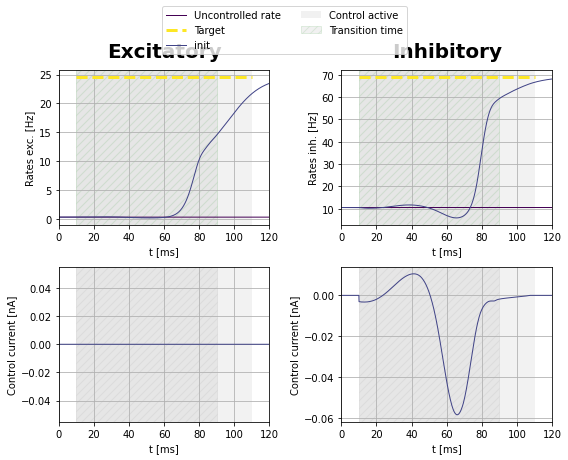

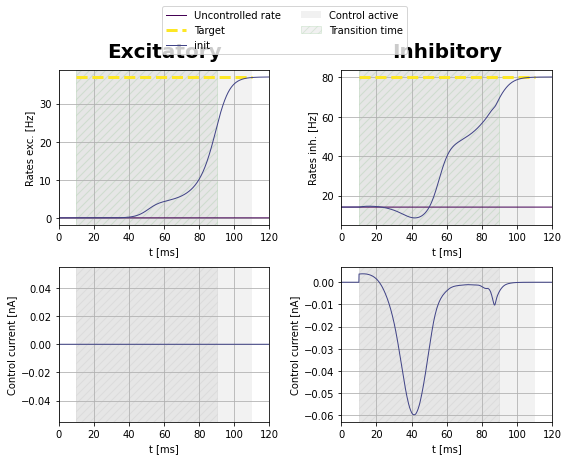

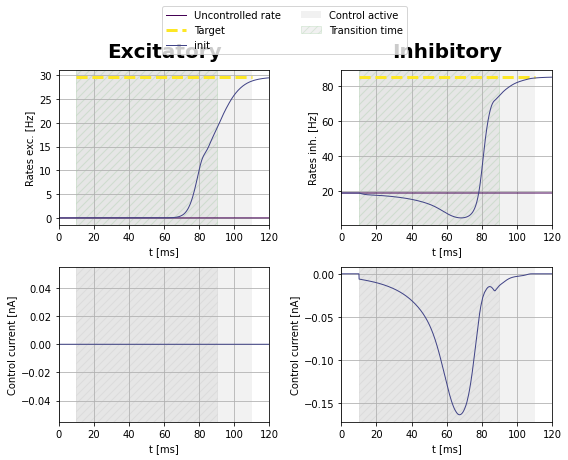

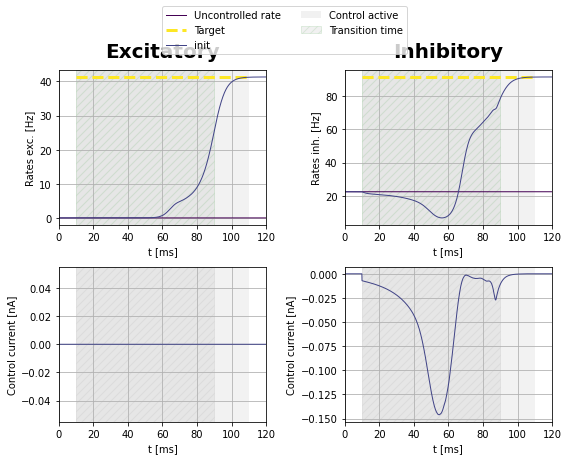

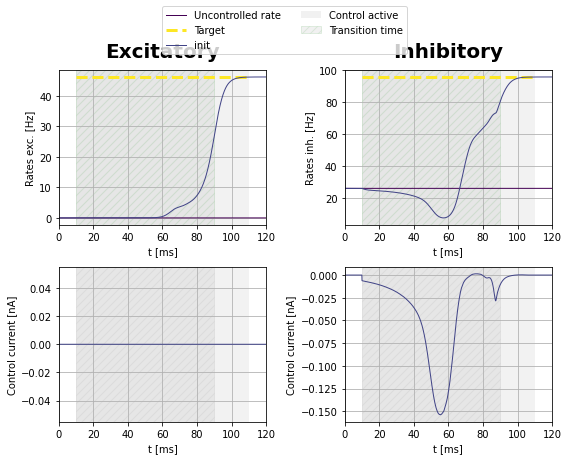

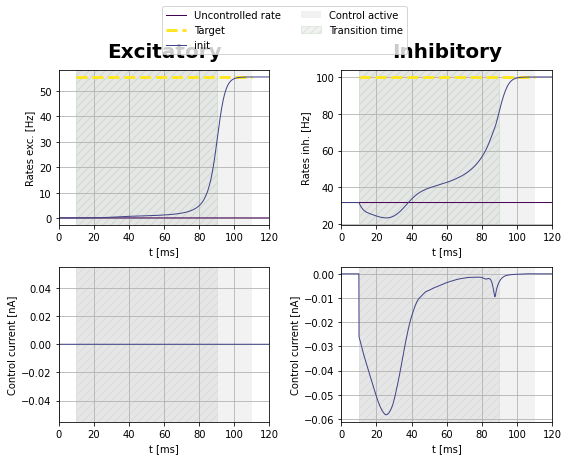

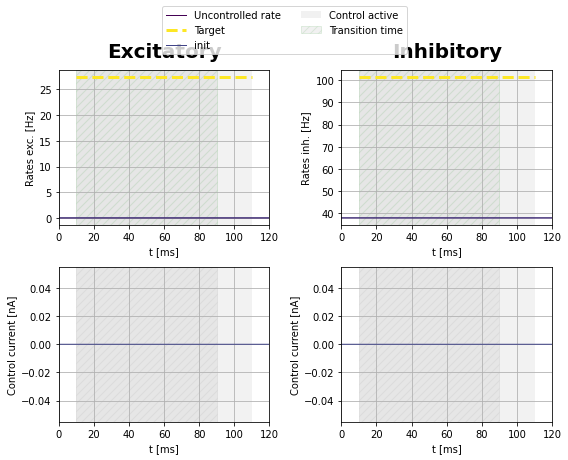

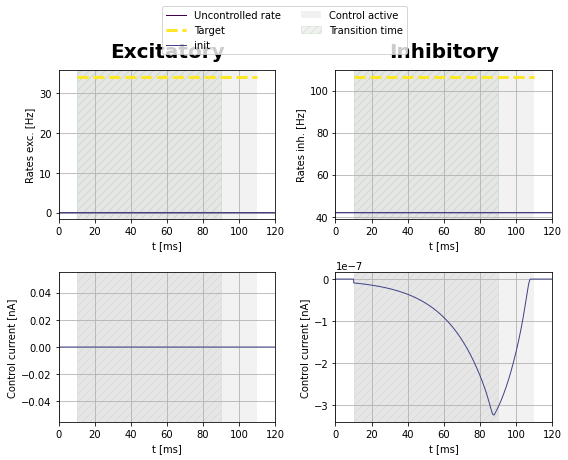

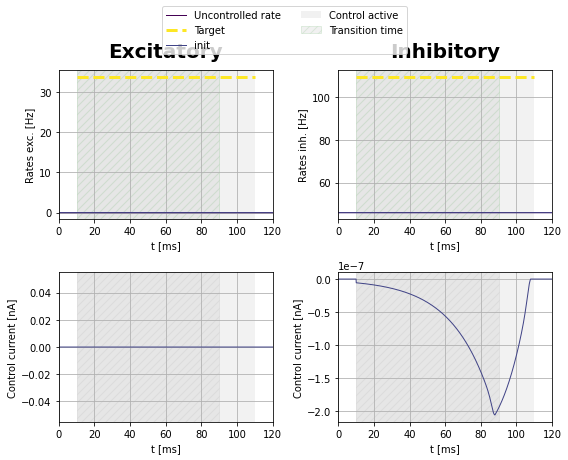

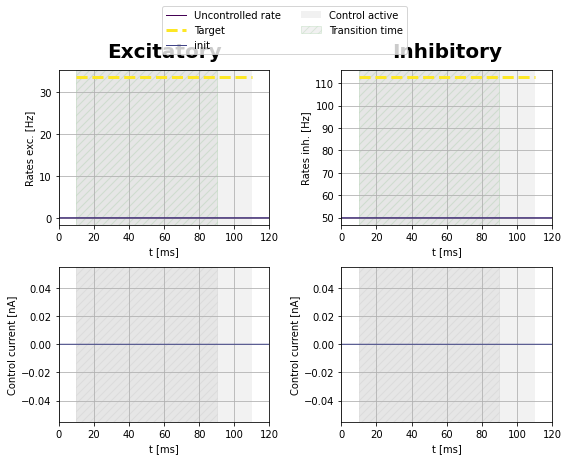

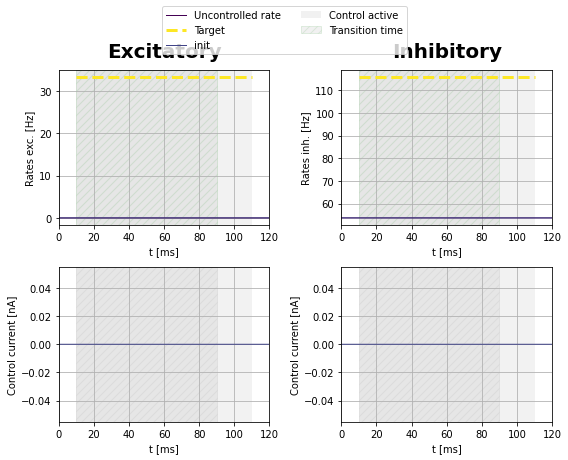

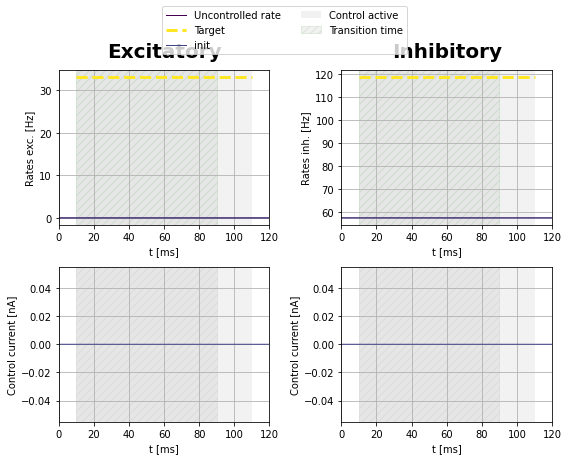

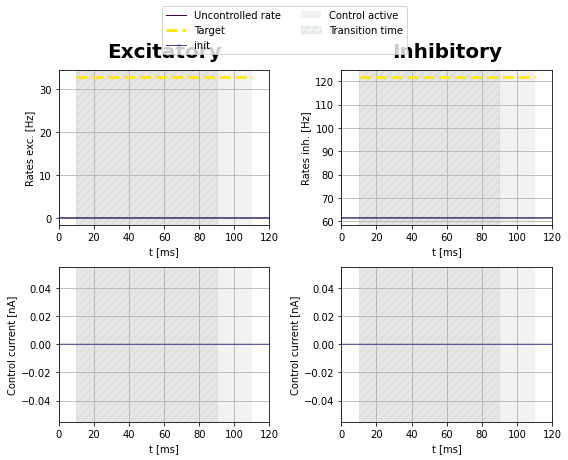

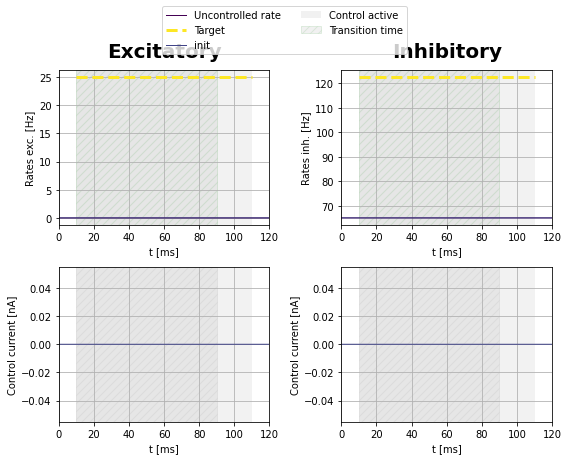

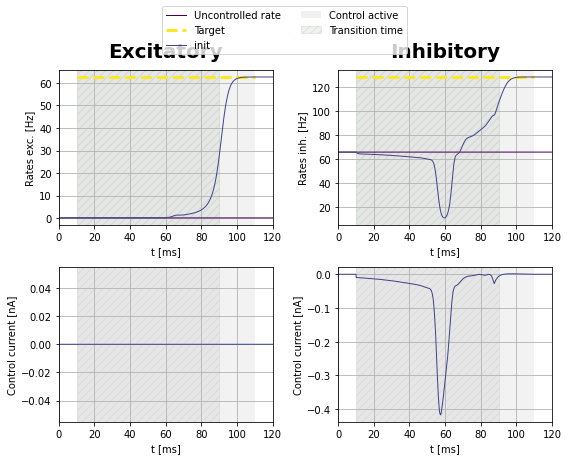

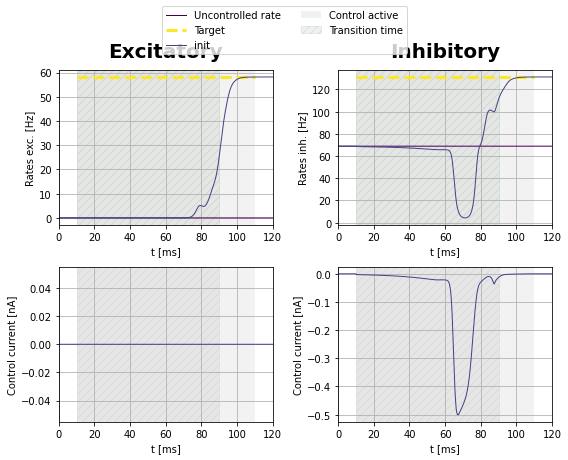

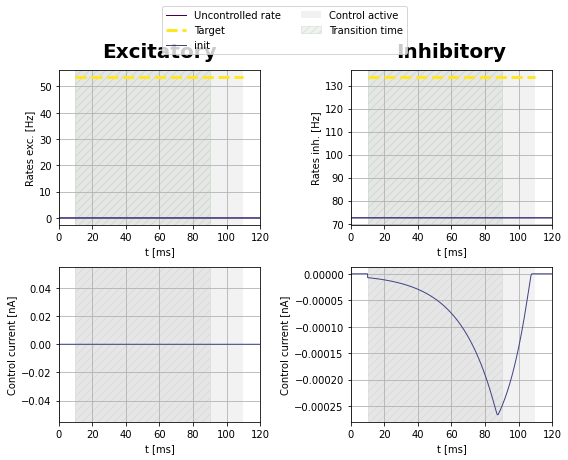

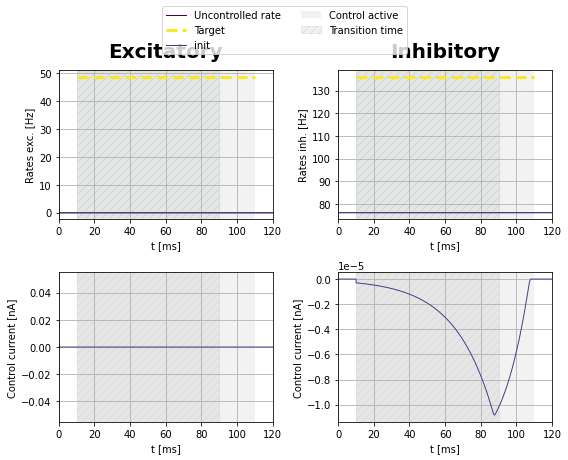

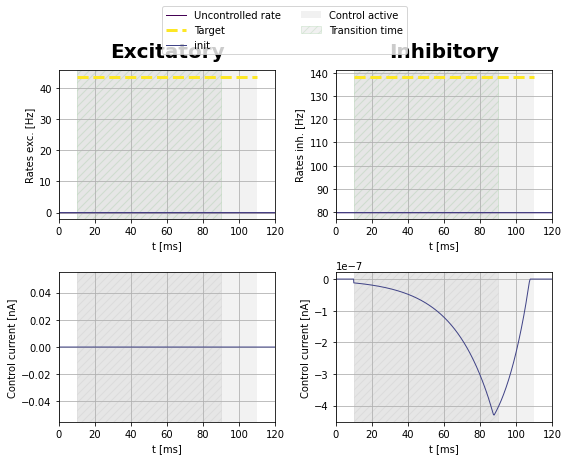

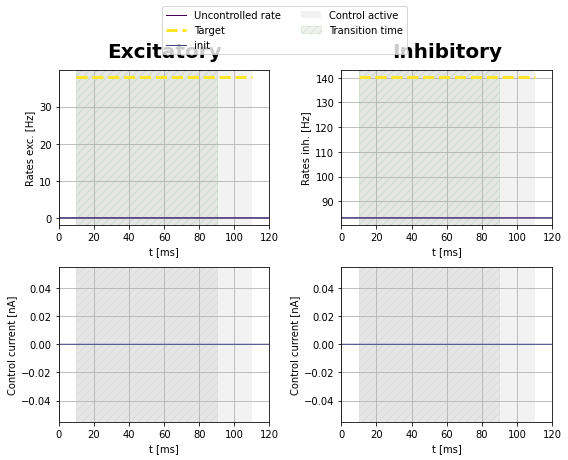

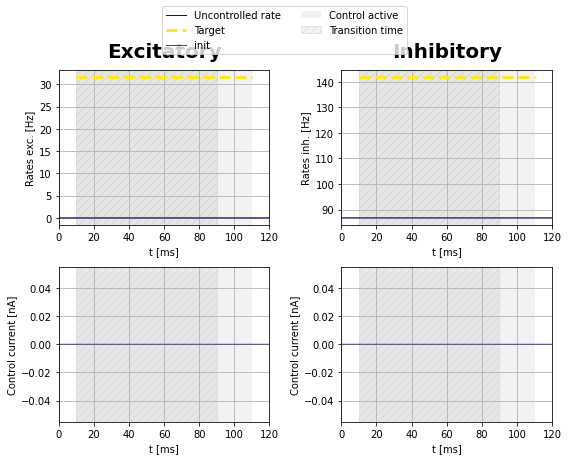

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
found solution for  14
-------  

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7519.183505039465
Control only changes marginally.
RUN  1 , total integrated cost =  7519.183505039465
Improved over  1  iterations in  0.0513151828199625  seconds by  0.0  percent.
-------  49 0.4500000000000001 0.6000000000000003
[0, 7, 14, 21, 28, 35] []
closest index  28
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11656.04014465924
Gradient descend method:  None
RUN  1 , total integrated cost =  11617.461862334409
RUN  2 , total integrated cost =  11617.452451313475
RUN  3 , total integrated cost =  11617.452449017836
RUN  4 , total integrated cost =  11617.452449017184
RUN  5 , total integrated cost =  11617.452449017183
RUN  6 , total integrated cost =  11617.452449017183
Control only changes marginally.
RUN  6 , total integrated cost =  11617.452449017183
Improved over  6  iterations in  0.17690441012382507  seconds by  0.33105321501263063  percent.
Problem in initi

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  11617.452449017183
Control only changes marginally.
RUN  1 , total integrated cost =  11617.452449017183
Improved over  1  iterations in  0.053498053923249245  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -77.02689918947686 -77.02689920903339
-------  56 0.4500000000000001 0.6250000000000003
[0, 7, 14, 21, 28, 35] []
closest index  28
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11475.757334255804
Gradient descend method:  None
RUN  1 , total integrated cost =  11437.17890565356
RUN  2 , total integrated cost =  11437.16948901105
RUN  3 , total integrated cost =  11437.169486712579
RUN  4 , total integrated cost =  11437.169486711975
RUN  5 , total integrated cost =  11437.169486711973
RUN  6 , total integrated cost =  11437.169486711973
Control only changes marginally.
RUN  6 , total integrated cost =  11437.169486711973
Improved over  6  iteratio

...

RUN  40 , total integrated cost =  10985.613460625189
Control only changes marginally.
RUN  46 , total integrated cost =  10985.613460625109
Improved over  46  iterations in  1.0623825397342443  seconds by  2.773845613606028  percent.
Problem in initial value trasfer:  Vmean_exc -56.66037463773807 -56.66039055450297
-------  63 0.4500000000000001 0.6500000000000004
[0, 7, 14, 21, 28, 35, 98, 105, 112, 119, 126, 70, 77, 133, 140] [28, 35, 105, 21]
closest index  70
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  438.3383391939043
Gradient descend method:  None
RUN  1 , total integrated cost =  393.3049805108794
RUN  2 , total integrated cost =  390.16854359960615
RUN  3 , total integrated cost =  389.16336001909815
RUN  4 , total integrated cost =  389.16334765452297
RUN  5 , total integrated cost =  389.16334759066814
RUN  6 , total integrated cost =  389.1633475906664
RUN  7 , total integrated cost =  389.163

ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  389.1633475906657
Control only changes marginally.
RUN  9 , total integrated cost =  389.1633475906657
Improved over  9  iterations in  0.2564757540822029  seconds by  11.218501145409832  percent.
Problem in initial value trasfer:  Vmean_exc -56.65999882425859 -56.660000310834626
weight =  289.54822754572274
set cost params:  1.0 289.54822754572274 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  11154.353086246194
Gradient descend method:  None
RUN  1 , total integrated cost =  10917.350895928057
RUN  2 , total integrated cost =  10917.350895928053
RUN  3 , total integrated cost =  10917.350895928052


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  10917.350895928052
Control only changes marginally.
RUN  4 , total integrated cost =  10917.350895928052
Improved over  4  iterations in  0.23097528889775276  seconds by  2.124750655512031  percent.
Problem in initial value trasfer:  Vmean_exc -56.659234230469316 -56.659250548944854
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
found solution for  84
-------  91 0.4250000000000001 0.7500000000000004
found solution for  91
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.8750000000000006
-------  140 0.4500000000000001 0.9000000000000006
------------------------------------------------------------
------------------

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  9396.47525873231
set cost params:  1.0 9396.47525873231 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5712.637878437198
Gradient descend method:  None
RUN  1 , total integrated cost =  5683.073682224552
RUN  2 , total integrated cost =  5683.054707986723
RUN  3 , total integrated cost =  5683.053536663298
RUN  4 , total integrated cost =  5683.05343228486
RUN  5 , total integrated cost =  5683.053425650471
RUN  6 , total integrated cost =  5683.053425196076
RUN  7 , total integrated cost =  5683.053425155928
RUN  8 , total integrated cost =  5683.053425

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  5683.053425153235
RUN  13 , total integrated cost =  5683.053425153235
Control only changes marginally.
RUN  13 , total integrated cost =  5683.053425153235
Improved over  13  iterations in  0.36466473899781704  seconds by  0.5178772733981987  percent.
Problem in initial value trasfer:  Vmean_exc -56.62957259730453 -56.629433884473144
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  22437.09053021965
set cost params:  1.0 22437.09053021965 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13508.270754690708
Gradient descend method:  None
RUN  1 , total integrated cost =  13505.618914292807
RUN  2 , total integrated cost =  13505.530209458708
RUN  3 , total integrated cost =  13505.517532818294
RUN  4 , total integrated cost =  13505.516280936134
RUN  5 , total integrated cost =  13505.516212977129
RUN  6 , total integrated cost =  13505.516194541946
RUN  7 , total integrated cost =  13505.51618580077

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  27 , total integrated cost =  13505.516170587904
Improved over  27  iterations in  0.6792639121413231  seconds by  0.02039183366122188  percent.
Problem in initial value trasfer:  Vmean_exc -56.673593348300635 -56.67360783545446
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  1432.8314628478886
set cost params:  1.0 1432.8314628478886 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8753.544575739186
Gradient descend method:  None
RUN  1 , total integrated cost =  8751.973520802496
RUN  2 , total integrated cost =  8751.927402624922
RUN  3 , total integrated cost =  8751.924587341666
RUN  4 , total integrated cost =  8751.924390357566
RUN  5 , total integrated cost =  8751.9243656175
RUN  6 , total integrated cost =  8751.92436329409
RUN  7 , total integrated cost =  8751.924362928869


...

RUN  3 , total integrated cost =  23702.71589974989
Control only changes marginally.
RUN  3 , total integrated cost =  23702.71589974989
Improved over  3  iterations in  0.18050828762352467  seconds by  1.9895196601282805e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.70094712936527 -56.70094770376828
-------  126 0.5000000000000002 0.8500000000000005
no convergence
weight =  279.5111761812492
set cost params:  1.0 279.5111761812492 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18934.237997377626
Gradient descend method:  None
RUN  1 , total integrated cost =  18934.237997377626
Control only changes marginally.
RUN  1 , total integrated cost =  18934.237997377626
Improved over  1  iterations in  0.07524199597537518  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69246802880184 -56.69246997769929
-------  133 0.47500000000000014 0.8750000000000006
no convergence
weight =  159.88081301442037
set cost params:  1.0 1

ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  14356.845843397747
RUN  3 , total integrated cost =  14356.845843397743
RUN  4 , total integrated cost =  14356.845843397743
Control only changes marginally.
RUN  4 , total integrated cost =  14356.845843397743
Improved over  4  iterations in  0.21059530600905418  seconds by  2.5579538487363607e-13  percent.
Problem in initial value trasfer:  Vmean_exc -56.67652205256614 -56.67652936343404
-------  140 0.4500000000000001 0.9000000000000006
no convergence
weight =  85.82555309409996
set cost params:  1.0 85.82555309409996 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9904.565066931074
Gradient descend method:  None
RUN  1 , total integrated cost =  9904.56506693107


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  9904.56506693107
Control only changes marginally.
RUN  2 , total integrated cost =  9904.56506693107
Improved over  2  iterations in  0.1257156040519476  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.650405644183195 -56.65042606067921


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[False, False], [True, True], [False, False], [True, True], [False, False], [True, True], [False, False], [True, True], [False, False], [True, True], [True, True], [False, False], [True, True], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  655.2128320031326
Gradient descend method:  None
RUN  1 , total integrated cost =  13.539237775643471
RUN  2 , total integrated cost =  13.440130638510455
RUN  3 , total integrated cost =  13.433057591325813
RUN  4 , total integrated cost =  13.426115680177967
RUN  5 , total integrated cost =  13.40157590542223
RUN  6 , total integrated cost =  13.385519319140133
RUN  7 , total integrated cost =  13.379785360403897
RUN  8 , total integrated cost =  13.378480910407028
RUN  9 , total integrated cost =  13.35986186184562
RUN  10 , total integrated cost =  13.32495598062262
RUN  11 , total integrated cost =  13.321149679274242
RUN  12 , total integrated cost =  13.310064765453092
RUN  13 , total integrated cost =  13.306995637679217
RUN  14 , total integrated cost =  13.305880763074718
RUN  15 , total integrated cost =  13.305555762552324
R

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  13.278915972307116
State only changes marginally.
Control only changes marginally.
RUN  42 , total integrated cost =  13.278915972307113
Improved over  42  iterations in  2.776666235178709  seconds by  97.97334311483026  percent.
Problem in initial value trasfer:  Vmean_exc -56.62764024365792 -56.62763976718905
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  82.55240107182865
Gradient descend method:  HS
RUN  1 , total integrated cost =  79.43967741952204
RUN  2 , total integrated cost =  78.53174780756281
RUN  3 , total integrated cost =  75.28268451349761
RUN  4 , total integrated cost =  74.97198036970961
RUN  5 , total integrated cost =  71.6636999796881
RUN  6 , total integrated cost =  69.04108551390419
RUN  7 , total integrated cost =  68.23161766250847
RUN  8 , total integrated cost =  67.11166617286553
RUN  9 , total integrated cost =  67.04059817075313
RUN  10 , total inte

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  269 , total integrated cost =  33.950325075880116
Improved over  269  iterations in  18.879231804981828  seconds by  58.87421245768489  percent.
Problem in initial value trasfer:  Vmean_exc -56.6276175926609 -56.62761767709307
weight =  17384.419627194457
set cost params:  1.0 17384.419627194457 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5880.050315066305
Gradient descend method:  None
RUN  1 , total integrated cost =  5618.9686867636665
RUN  2 , total integrated cost =  5615.723722615415
RUN  3 , total integrated cost =  5568.2346361873715
RUN  4 , total integrated cost =  5539.459086427877
RUN  5 , total integrated cost =  5539.401492383789
RUN  6 , total integrated cost =  5539.39106999304
RUN  7 , total integrated cost =  5539.387565527464
RUN  8 , total integrated cost =  5539.385222956435
RUN  9 , total integrated cost =  5539.383359412842
RUN  10 , total integrated cost =  5539.381208515532
RUN  11 , total in

...

Control only changes marginally.
RUN  92 , total integrated cost =  6647.268609372004
Improved over  92  iterations in  7.1141960602253675  seconds by  18.27187596575139  percent.
Problem in initial value trasfer:  Vmean_exc -56.67651430412748 -56.67652654229953
weight =  216.3320181637347
set cost params:  1.0 216.3320181637347 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14379.734246605509
Gradient descend method:  None
RUN  1 , total integrated cost =  14314.952729097256
RUN  2 , total integrated cost =  14277.198836965432
RUN  3 , total integrated cost =  14210.280564712459
RUN  4 , total integrated cost =  14173.613493419638
RUN  5 , total integrated cost =  14110.882973338948
RUN  6 , total integrated cost =  13518.553235114912
RUN  7 , total integrated cost =  10926.747510815489
RUN  8 , total integrated cost =  10799.901390246265
RUN  9 , total integrated cost =  10435.01253618579
RUN  10 , total integrated cost =  9086.336095341254
RUN  11 , tota

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  211 , total integrated cost =  4868.404288986369
Improved over  211  iterations in  12.409282695502043  seconds by  66.14398982974524  percent.
Problem in initial value trasfer:  Vmean_exc -56.67686789199374 -56.67686655084716
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  232.24374636169864
Gradient descend method:  None
RUN  1 , total integrated cost =  153.78159074895913
RUN  2 , total integrated cost =  153.23449227232115
RUN  3 , total integrated cost =  153.126512260592
RUN  4 , total integrated cost =  153.06952862662558
RUN  5 , total integrated cost =  152.99824619909222
RUN  6 , total integrated cost =  152.9315027392862
RUN  7 , total integrated cost =  152.8785784766472
RUN  8 , total integrated cost =  152.82950876477472
RUN  9 , total integrated cost =  152.78731182774953
RUN  10 , total integrated cost =  152.74969359329924
RUN 

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  150.64166600389476
RUN  1000 , total integrated cost =  150.64166600389476
Improved over  1000  iterations in  62.51059641316533  seconds by  35.13639511770363  percent.
Problem in initial value trasfer:  Vmean_exc -56.65164610024477 -56.6516461980823
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10407.461905966295
Gradient descend method:  HS
RUN  1 , total integrated cost =  10029.322189070126
RUN  2 , total integrated cost =  10029.32159709622
RUN  3 , total integrated cost =  10019.973657449069
RUN  4 , total integrated cost =  10019.973656381804
RUN  5 , total integrated cost =  10019.968521405131
RUN  6 , total integrated cost =  10019.968521404546
RUN  7 , total integrated cost =  10019.968518583823
RUN  8 , total integrated cost =  10019.96851858382
RUN  9 , total integrated cost =  10019.968518582271
RUN  10 , total integrated cost =  10019.968518582271
Control only cha

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


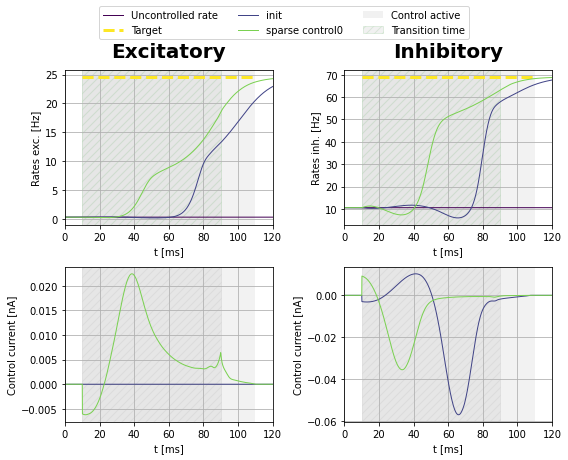

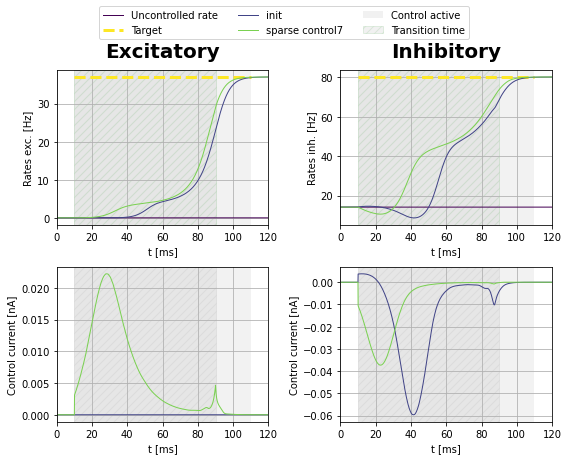

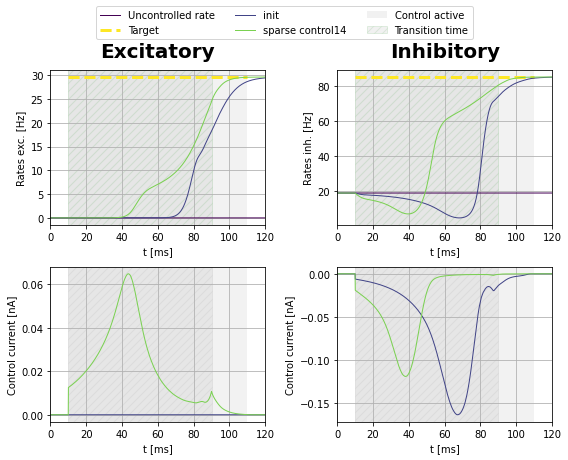

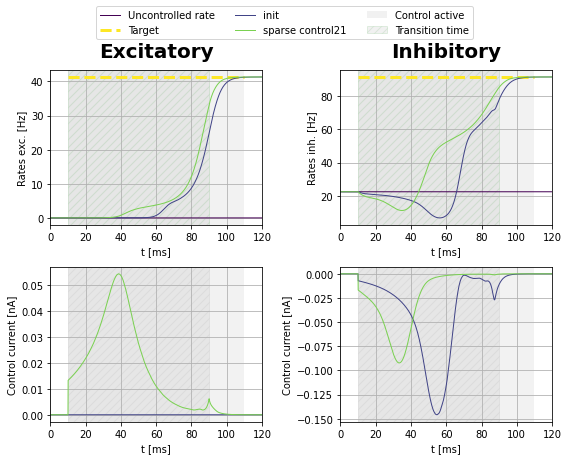

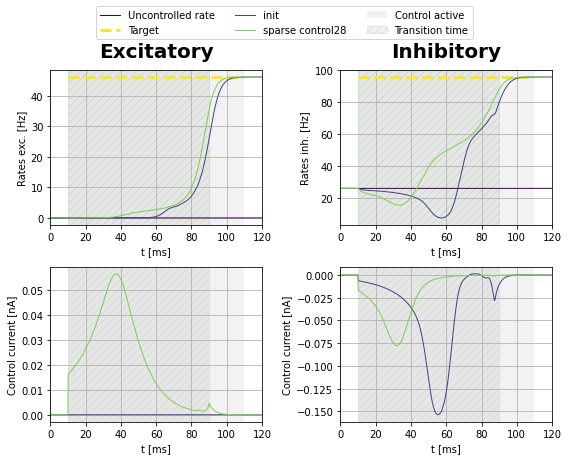

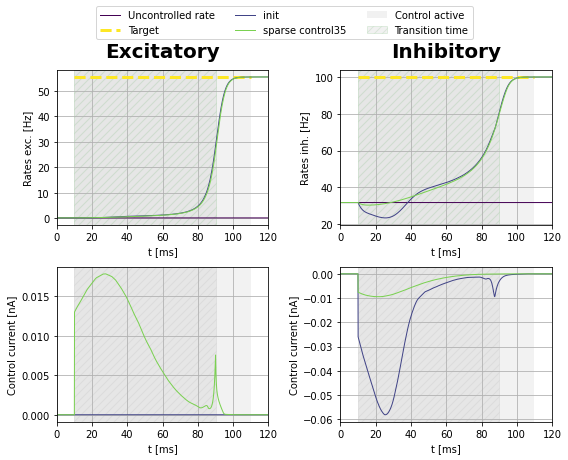

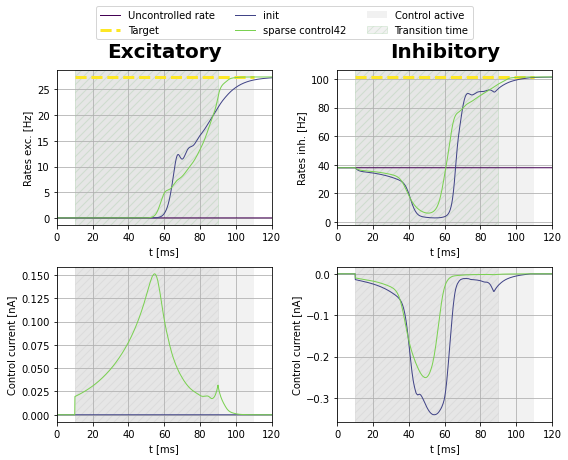

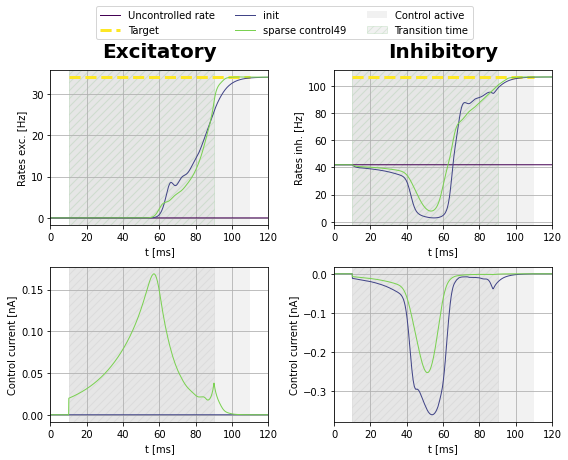

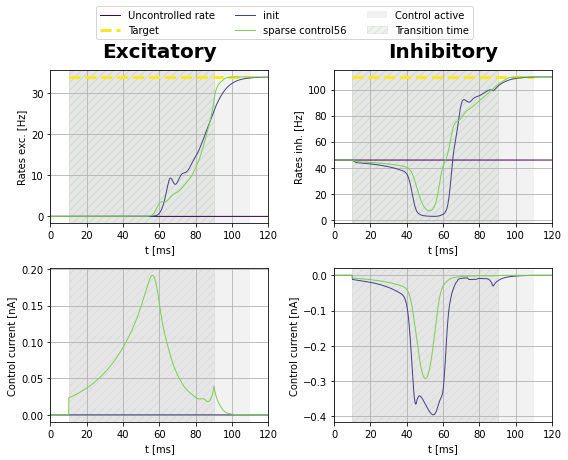

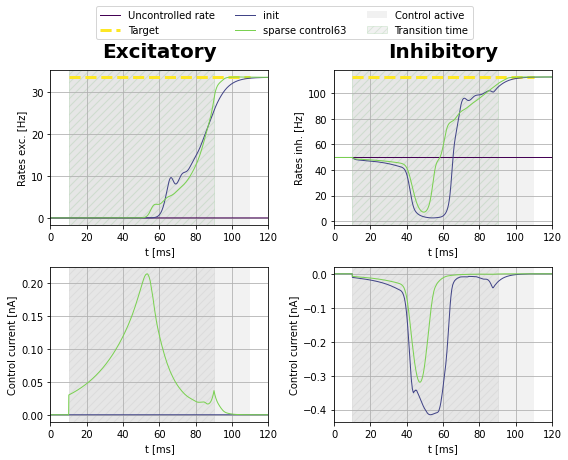

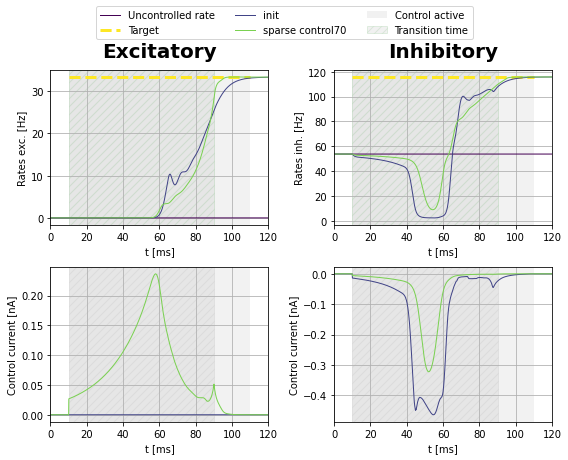

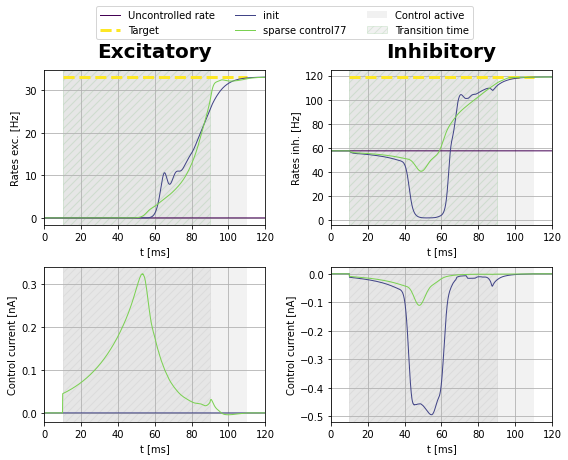

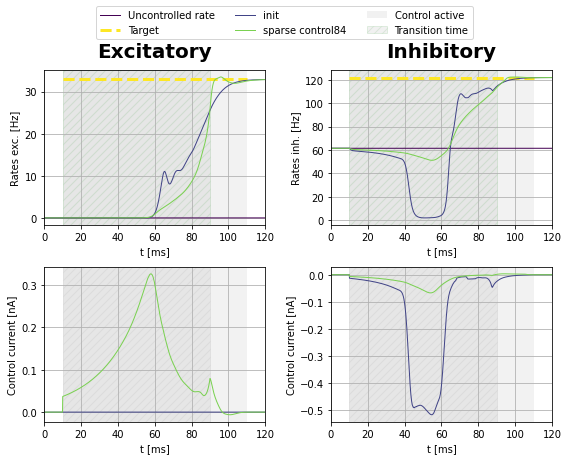

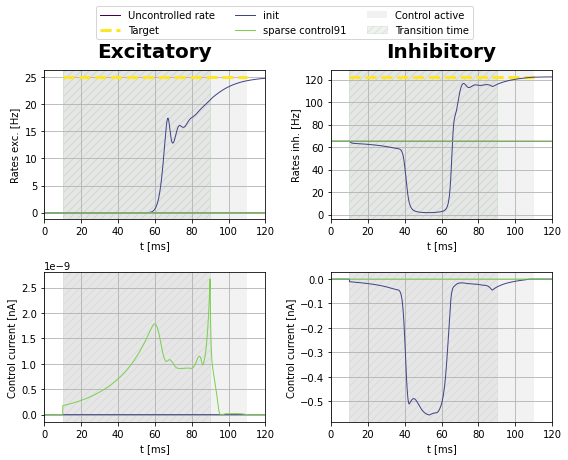

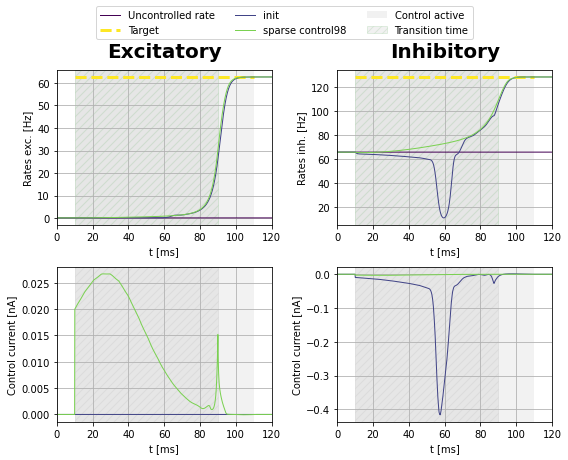

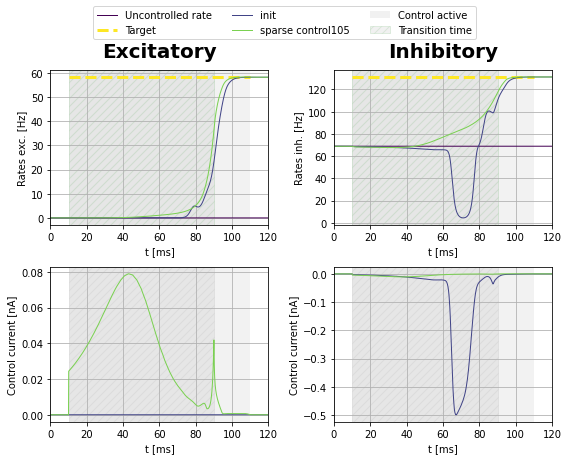

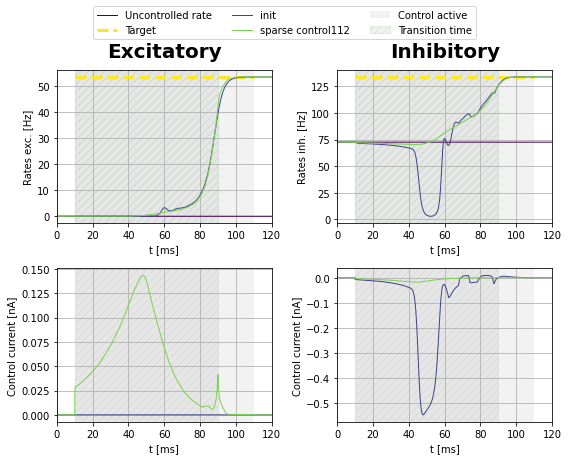

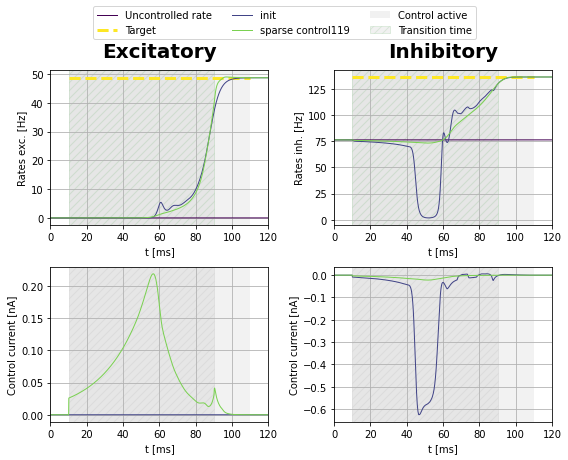

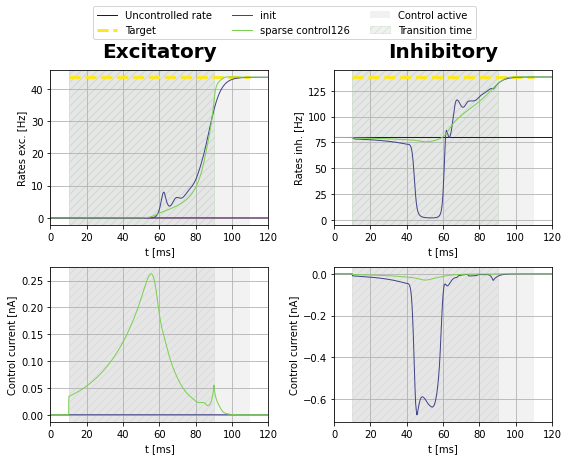

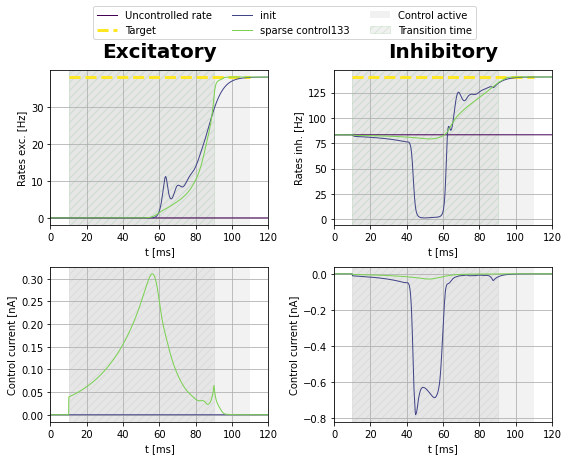

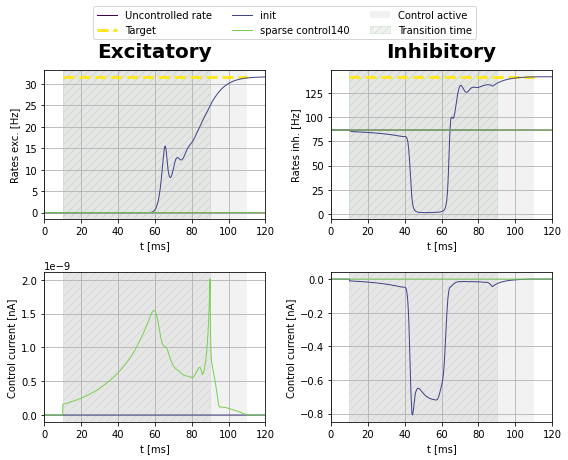

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  18540.723599997025
set cost params:  1.0 18540.723599997025 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5895.364461298775
Gradient descend method:  None
RUN  1 , total integrated cost =  5895.172339364329
RUN  2 , total integrated cost =  5895.1723393643115
RUN  3 , total integrated cost =  5895.172339364303


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5895.172339364302
RUN  5 , total integrated cost =  5895.172339364302
Control only changes marginally.
RUN  5 , total integrated cost =  5895.172339364302
Improved over  5  iterations in  0.7293161172419786  seconds by  0.003258864413453466  percent.
Problem in initial value trasfer:  Vmean_exc -56.62636389597762 -56.62637281649024
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  38856.378903830504
set cost params:  1.0 38856.378903830504 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13554.857276019717
Gradient descend method:  None
RUN  1 , total integrated cost =  13554.832402420307
RUN  2 , total integrated cost =  13554.832402420248
RUN  3 , total integrated cost =  13554.832402420237
RUN  4 , total integrated cost =  13554.832402420236


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  13554.832402420236
Control only changes marginally.
RUN  5 , total integrated cost =  13554.832402420236
Improved over  5  iterations in  0.7800836358219385  seconds by  0.00018350321936111413  percent.
Problem in initial value trasfer:  Vmean_exc -56.67395275412779 -56.6739581296211
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2445.171917711731
set cost params:  1.0 2445.171917711731 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8792.254103817586
Gradient descend method:  None
RUN  1 , total integrated cost =  8792.252273639393
RUN  2 , total integrated cost =  8792.252267146734
RUN  3 , total integrated cost =  8792.252267146712


...

Problem in initial value trasfer:  Vmean_exc -56.69977662412678 -56.699776012348536
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
no convergence
weight =  5102.664584725802
set cost params:  1.0 5102.664584725802 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28709.91537420703
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28709.91537420703
Control only changes marginally.
RUN  1 , total integrated cost =  28709.91537420703
Improved over  1  iterations in  0.2080903947353363  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408493174015 -56.704084759239336
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 10
[[True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  39221.17363715239
Control only changes marginally.
RUN  1 , total integrated cost =  39221.17363715239
Improved over  1  iterations in  0.21395494602620602  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69977662412678 -56.699776012348536
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
converged for  112
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 11
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, False], [True, True], [Tr

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  107.7772097835438
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5944577933411372
RUN  2 , total integrated cost =  0.5839925622838602
RUN  3 , total integrated cost =  0.5834389075416196
RUN  4 , total integrated cost =  0.5751570805408686
RUN  5 , total integrated cost =  0.5710367671941932
RUN  6 , total integrated cost =  0.570608369183574
RUN  7 , total integrated cost =  0.5257455585285281
RUN  8 , total integrated cost =  0.49181614317729927
RUN  9 , total integrated cost =  0.49158173211877554
RUN  10 , total integrated cost =  0.4873056690071228
RUN  11 , total integrated cost =  0.48055895390569914
RUN  12 , total integrated cost =  0.4803192692695637
RUN  13 , total integrated cost =  0.479093807894612
RUN  14 , total integrated cost =  0.4761179406813323
RUN  15 , total integrated cost =  0.475783702848132

ERROR:root:Problem in initial value trasfer


RUN  50 , total integrated cost =  0.3691979995016115
Control only changes marginally.
RUN  53 , total integrated cost =  0.36919799950160836
Improved over  53  iterations in  1.2371410317718983  seconds by  99.65744334981106  percent.
Problem in initial value trasfer:  Vmean_exc -56.627616572179036 -56.62761659251697
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  75.78381496809604
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3740135726718832
RUN  2 , total integrated cost =  0.37400837988399616
RUN  3 , total integrated cost =  0.37266271653044275
RUN  4 , total integrated cost =  0.3713483755308683
RUN  5 , total integrated cost =  0.371346131900243
RUN  6 , total integrated cost =  0.3713427549540864
RUN  7 , total integrated cost =  0.37088990691405443
RUN  8 , total integrated cost =  0.3705813141864536
RUN  9 , total integrated cost =  0.37057938602097873

ERROR:root:Problem in initial value trasfer


RUN  110 , total integrated cost =  0.36756599799934325
Control only changes marginally.
RUN  118 , total integrated cost =  0.3675659979990247
Improved over  118  iterations in  2.571402022615075  seconds by  99.51498087269192  percent.
Problem in initial value trasfer:  Vmean_exc -56.67416751104619 -56.67416749720472
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  35.994531818887324
Gradient descend method:  None
RUN  1 , total integrated cost =  4.858449919299433
RUN  2 , total integrated cost =  4.85377457952738
RUN  3 , total integrated cost =  4.853768156149738
RUN  4 , total integrated cost =  4.853768008742724
RUN  5 , total integrated cost =  4.853768004621803
RUN  6 , total integrated cost =  4.8537680044875104
RUN  7 , total integrated cost =  4.85376800448447
RUN  8 , total integrated cost =  4.8537680044843885


...

RUN  80 , total integrated cost =  14.78366678774112
Control only changes marginally.
RUN  81 , total integrated cost =  14.78366678774112
Improved over  81  iterations in  1.7390573378652334  seconds by  90.2274215907819  percent.
Problem in initial value trasfer:  Vmean_exc -56.700970737562635 -56.700970402603396
-------  126 0.5000000000000002 0.8500000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  74.56604283030899
Gradient descend method:  None
RUN  1 , total integrated cost =  19.02016581119625
RUN  2 , total integrated cost =  18.930781957978887
RUN  3 , total integrated cost =  18.929222318074878
RUN  4 , total integrated cost =  18.908018285819225
RUN  5 , total integrated cost =  18.87522888177162
RUN  6 , total integrated cost =  18.873769912043752
RUN  7 , total integrated cost =  18.85774441810193
RUN  8 , total integrated cost =  18.83144217014292
RUN  9 , total integrated cost =  18.829957321163203
RUN  10 

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  18.292395279004836
Control only changes marginally.
RUN  45 , total integrated cost =  18.292395279003713
Improved over  45  iterations in  1.0122849587351084  seconds by  75.46819626645338  percent.
Problem in initial value trasfer:  Vmean_exc -56.69254463059519 -56.69254446466529
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50.765775513433276
Gradient descend method:  None
RUN  1 , total integrated cost =  24.394878691955185
RUN  2 , total integrated cost =  24.38457140679664
RUN  3 , total integrated cost =  24.38425856980299
RUN  4 , total integrated cost =  24.362848818730914
RUN  5 , total integrated cost =  24.334590115394484
RUN  6 , total integrated cost =  24.334181765389285
RUN  7 , total integrated cost =  24.333947912567037
RUN  8 , total integrated cost =  24.31386101015681
RUN  9 , total integrated cost =  24.284776481608475
RUN 

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  24.070915425592432
Control only changes marginally.
RUN  21 , total integrated cost =  24.070915425592432
Improved over  21  iterations in  0.5395573023706675  seconds by  52.58436381175156  percent.
Problem in initial value trasfer:  Vmean_exc -56.676877460557016 -56.67687627452485
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost =  10019.968518582271
Control only changes marginally.
RUN  1 , total integrated cost =  10019.968518582271
Improved over  1  iterations in  0.046898165717720985  seconds by  0.0  percent.


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.36919799950160836
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.36919799950160836
Control only changes marginally.
RUN  1 , total integrated cost =  0.36919799950160836
Improved over  1  iterations in  0.07532617263495922  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627616572179036 -56.62761659251697
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3675659979990247
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3675659979990247
Control only changes marginally.
RUN  1 , total integrated cost =  0.3675659979990247
Improved over  1  iterations in  0.06367694772779942  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67416751104619 -56.67416749720472
-------  14 0.4250000000000001 0.4500000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.8537680

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.853768004484365
Control only changes marginally.
RUN  1 , total integrated cost =  4.853768004484365
Improved over  1  iterations in  0.06984591297805309  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64464724541174 -56.64463648235778
-------  21 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.267301522798557
Gradient descend method:  None


...

RUN  1 , total integrated cost =  5.9947050148115135
Control only changes marginally.
RUN  1 , total integrated cost =  5.9947050148115135
Improved over  1  iterations in  0.06465658731758595  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408454563102 -56.70408443930455
-------  119 0.5250000000000001 0.8250000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.78366678774112
Gradient descend method:  None
RUN  1 , total integrated cost =  14.78366678774112
Control only changes marginally.
RUN  1 , total integrated cost =  14.78366678774112
Improved over  1  iterations in  0.06612358056008816  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700970737562635 -56.700970402603396
-------  126 0.5000000000000002 0.8500000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18.29239527

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  18.292395279003713
Control only changes marginally.
RUN  1 , total integrated cost =  18.292395279003713
Improved over  1  iterations in  0.06664086319506168  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69254463059519 -56.69254446466529
-------  133 0.47500000000000014 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24.070915425592432
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  24.070915425592432
Control only changes marginally.
RUN  1 , total integrated cost =  24.070915425592432
Improved over  1  iterations in  0.06572665274143219  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.676877460557016 -56.67687627452485
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 19
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
---

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
